### Setting up the notebook

In [1]:
import warnings
warnings.simplefilter(action="ignore")

import numpy as np
import pandas as pd

from dslab import distribution

from sklearn import set_config
set_config(transform_output="pandas")

%matplotlib inline
%load_ext autoreload
%autoreload 2

### Loading the data

In [2]:
train_df = pd.read_csv("data\\train.csv", index_col=0, na_values="NA", keep_default_na=False)
test_df = pd.read_csv("data\\test.csv", index_col=0, na_values="NA", keep_default_na=False)

### Split test and train data

In [3]:
def split_features(df, target):
    if target: 
        X = df.drop("SalePrice", axis=1)
        y = df["SalePrice"].copy()
        return X, y
    else:
        X = df.copy()
        return X

X_train, y_train = split_features(train_df, True)
X_test = split_features(test_df, False)

### Split categorical and numerical data

In [4]:
X_train_num = X_train.select_dtypes(np.number)
X_train_cat = X_train.select_dtypes(object)

X_test_num = X_test.select_dtypes(np.number)
X_test_cat = X_test.select_dtypes(object)

### Creating new features

In [5]:
X_train_num["AvgRoomArea"] = X_train_num["GrLivArea"] / X_train_num["TotRmsAbvGrd"]
X_train_num["LogGrLivArea"] = np.log(X_train_num["GrLivArea"])
X_train_num["LogLotArea"] = np.log(X_train_num["LotArea"])

X_test_num["AvgRoomArea"] = X_test_num["GrLivArea"] / X_test_num["TotRmsAbvGrd"]
X_test_num["LogGrLivArea"] = np.log(X_test_num["GrLivArea"])
X_test_num["LogLotArea"] = np.log(X_test_num["LotArea"])

### Impute missing data

In [6]:
from sklearn.impute import SimpleImputer
imputer = SimpleImputer(missing_values=np.nan)
X_train_num = imputer.fit_transform(X_train_num).astype(np.float32)
X_test_num = imputer.transform(X_test_num).astype(np.float32)

### Encode categorical data

In [7]:
from sklearn.preprocessing import OneHotEncoder
from sklearn import set_config
set_config(transform_output="pandas")

onehot_encoder = OneHotEncoder(sparse_output=False, handle_unknown="ignore")
X_train_cat = onehot_encoder.fit_transform(X_train_cat).astype(bool)
X_test_cat = onehot_encoder.transform(X_test_cat).astype(bool)

X_train_out = pd.concat([X_train_num, X_train_cat], axis = 1)
X_test_out = pd.concat([X_test_num, X_test_cat], axis = 1)

### Refactoring transformations into a function

In [17]:
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import OneHotEncoder

import numpy as np


def feature_generation(df):
    """
    Generate additional features for the given dataframe.

    This function generates new features based on existing columns.

    Parameters:
    df (dataframe): The input dataframe containing the original features.

    Returns:
    updated_df (dataframe): A new dataframe with the original and newly generated features.
    """

    # Copy the input DataFrame to make changes to
    updated_df = df.copy()

    # Features from original code
    updated_df["AvgRoomArea"] = df["GrLivArea"] / df["TotRmsAbvGrd"]
    updated_df["LogGrLivArea"] = np.log(df["GrLivArea"])
    updated_df["LogLotArea"] = np.log(df["LotArea"])

    # Transform right skewed data
    skewed_features = ["LotFrontage", "LotArea", "MasVnrArea", "BsmtFinSF1", "BsmtFinSF2", "BsmtUnfSF", "TotalBsmtSF", "1stFlrSF", "2ndFlrSF", "LowQualFinSF", "GrLivArea", "GarageArea", "WoodDeckSF", "OpenPorchSF", "EnclosedPorch", "3SsnPorch", "ScreenPorch", "PoolArea", "MiscVal"]
    for feature in skewed_features:
        updated_df[f"Log{feature}"] = np.log1p(df[feature])

    # Additional features
    updated_df["TotalSqFt"] = df["GrLivArea"] + df["TotalBsmtSF"] + df["GarageArea"]
    updated_df["QualGrLivArea"] = df["OverallQual"] * df["GrLivArea"]
    updated_df["QualTotalSqFt"] = df["OverallQual"] * updated_df["TotalSqFt"]
    updated_df["HouseAge"] = df["YrSold"] - df["YearBuilt"]
    updated_df["RemodAge"] = df["YrSold"] - df["YearRemodAdd"]
    updated_df["TotalPorchSF"] = df["OpenPorchSF"] + df["EnclosedPorch"] + df["3SsnPorch"] + df["ScreenPorch"]
    updated_df["BsmtToLivingAreaRatio"] = df["TotalBsmtSF"] / df["GrLivArea"]
    updated_df["LotAreaPerRoom"] = df["LotArea"] / df["TotRmsAbvGrd"]
    updated_df["TotalBath"] = df["FullBath"] + 0.5 * df["HalfBath"] + df["BsmtFullBath"] + 0.5 * df["BsmtHalfBath"]
    updated_df["TotalRooms"] = df["TotRmsAbvGrd"] + df["BedroomAbvGr"]
    updated_df["GarageAge"] = df["YrSold"] - df["GarageYrBlt"]
    updated_df["TotalHouseArea"] = df["1stFlrSF"] + df["2ndFlrSF"] + df["TotalBsmtSF"]
    updated_df["TotalHouseQuality"] = df["OverallQual"] * updated_df["TotalHouseArea"]
    updated_df["TotalHouseCondition"] = df["OverallCond"] * updated_df["TotalHouseArea"]
    updated_df["TotalHouseAge"] = df["YrSold"] - df["YearBuilt"]
    updated_df["TotalHouseRemodAge"] = df["YrSold"] - df["YearRemodAdd"]
    updated_df["TotalHousePorchSF"] = df["OpenPorchSF"] + df["EnclosedPorch"] + df["3SsnPorch"] + df["ScreenPorch"] + df["WoodDeckSF"]
    updated_df["TotalHouseBath"] = df["FullBath"] + df["BsmtFullBath"] + df["HalfBath"] + df["BsmtHalfBath"]

    # Squared features
    updated_df["GrLivAreaSquared"] = df["GrLivArea"] ** 2
    updated_df["LotAreaSquared"] = df["LotArea"] ** 2
    updated_df["TotalBsmtSFSquared"] = df["TotalBsmtSF"] ** 2
    updated_df["GarageAreaSquared"] = df["GarageArea"] ** 2
    updated_df["OverallQualSquared"] = df["OverallQual"] ** 2
    updated_df["OverallCondSquared"] = df["OverallCond"] ** 2
    updated_df["TotalHouseAreaSquared"] = updated_df["TotalHouseArea"] ** 2
    updated_df["TotalHouseQualitySquared"] = updated_df["TotalHouseQuality"] ** 2
    updated_df["TotalHouseConditionSquared"] = updated_df["TotalHouseCondition"] ** 2
    updated_df["TotalHousePorchSFSquared"] = updated_df["TotalHousePorchSF"] ** 2
    updated_df["TotalHouseBathSquared"] = updated_df["TotalHouseBath"] ** 2
    updated_df["TotalHouseFireplacesSquared"] = updated_df["Fireplaces"] ** 2
    updated_df["TotalHouseGarageAreaSquared"] = updated_df["GarageArea"] ** 2
    updated_df["TotalHouseGarageCarsSquared"] = updated_df["GarageCars"] ** 2

    return updated_df

def process_X_data(df, test=False):
    """
    Processes the input dataframe by imputing missing values, encoding categorical variables, 
    and generating additional features. Also removes features with low correlation to the target variable,
    and ensures that test data has the same features as the training data.

    Parameters:
    df (dataframe): Input dataframe containing the features to be processed.
    test (bool, optional): A flag indicating whether the data is test data. Default is False.

    Returns:
    X_processed: A dataframe with processed numerical and categorical features.

    Notes:
    - When `test` is False, the function fits the imputer and encoder on the training data.
    - When `test` is True, the function uses the fitted imputer and encoder from the training data.
    - Features with a correlation to the target variable below a threshold of 0.05 are removed for train data.
    - For test data, only features present in the training data are kept to prevent errors for unseen variables.
    """

    # Split dataframe into numerical and categorical
    X_num = df.select_dtypes(np.number)
    X_cat = df.select_dtypes(object)

    # Add numerical features
    X_num = feature_generation(X_num)

    # Impute missing data using SimpleImputer
    if not test:
        global imputer
        imputer = SimpleImputer(strategy="most_frequent")
        X_num = imputer.fit_transform(X_num).astype(np.float32)
    else:
        X_num = imputer.transform(X_num).astype(np.float32)

    # Encode categorical data
    if not test:
        # Make onehot_encoder global to retain for later use
        global onehot_encoder
        onehot_encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
        X_cat = onehot_encoder.fit_transform(X_cat).astype(bool)
    else:
        X_cat = onehot_encoder.transform(X_cat).astype(bool)

    # Remove features with low correlation to target variable
    if not test:
        # Create correlation matrix
        corr_matrix = pd.concat([X_num, y_train], axis=1).corr()
        for feature in X_num.columns:
            # Remove features with correlation below threshold (can be changed)
            if abs(corr_matrix["SalePrice"][feature]) < 0:
                X_num = X_num.drop(feature, axis=1)

    # Ensure test data has the same features as training data
    if test:
        # Drop all columns that are not also present in the processed training data
        for feature in X_num.columns:
            if feature not in X_train_processed.columns:
                X_num = X_num.drop(feature, axis=1)

    # Concatenate processed numerical and categorical data and return
    X_processed = pd.concat([X_num, X_cat], axis = 1)
    return X_processed

## Lab 4

### Train models using standard parameters

In [10]:
from sklearn import linear_model
from sklearn import ensemble
from sklearn import svm
from sklearn import neighbors
from sklearn import tree
from sklearn import dummy
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import cross_val_predict
import pandas as pd

X_train_processed = process_X_data(X_train)
X_test_processed = process_X_data(X_test, True)

models = [
    linear_model.LinearRegression(),
    ensemble.RandomForestRegressor(),
    ensemble.GradientBoostingRegressor(), # Training two models from the ensemble family
    svm.SVR(),
    neighbors.KNeighborsRegressor(),
    tree.DecisionTreeRegressor(),
    dummy.DummyRegressor()
]

for model in models:
    model.fit(X_train_processed, y_train)

preds = [cross_val_predict(model, X_train_processed, y_train) for model in models]
rmse = lambda t, p: np.sqrt(mean_squared_error(t, p))

rmse_series = pd.Series()
for i, model in enumerate(models):
    rmse_series[str(model)] = rmse(y_train, preds[i])
rmse_series = rmse_series.sort_values()

print(rmse_series)

GradientBoostingRegressor()    26046.228755
RandomForestRegressor()        30054.435847
KNeighborsRegressor()          36654.722156
LinearRegression()             36833.051169
DecisionTreeRegressor()        37453.860316
DummyRegressor()               79471.412474
SVR()                          81354.659940
dtype: float64


### Find RMSE for all regressors (not part of assignment)

In [ ]:
"""
from sklearn.utils import all_estimators
from sklearn.metrics import mean_squared_error
import numpy as np

# Get all regressor models
all_regressors = [est for est in all_estimators(type_filter='regressor')]

# Initialize a list to store models
models = []

# Loop through each regressor and instantiate it
for name, RegressorClass in all_regressors:
    try:
        model = RegressorClass()
        models.append(model)
    except Exception as e:
        print(f"Could not instantiate {name}: {e}")

# Fit each model and calculate RMSE
for model in models:
    try:
        model.fit(X_train_processed, y_train)
        preds = model.predict(X_train_processed)
        rmse_num = np.sqrt(mean_squared_error(y_train, preds))
        print(f"Model: {model}")
        print(f"RMSE: {rmse_num}\n")
    except Exception as e:
        print(f"Could not fit/predict with {model}: {e}")
"""

### Short-list the top three most promising models

In [16]:
print(rmse_series)

DecisionTreeRegressor()           64.770406
RandomForestRegressor()        11011.430499
GradientBoostingRegressor()    13731.470696
KNeighborsRegressor()          29946.224773
LinearRegression()             30858.025628
DummyRegressor()               79413.604102
SVR()                          81368.688890
dtype: float64


The three most promising models are:
- GradientBoostingRegressor
- RandomForestRegressor
- KNeighborsRegressor

## Lab 6

### Optimise the hyperparameters of 3 different regression algorithms

#### GradientBoostingRegressor

In [40]:
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.model_selection import GridSearchCV

X_train_processed = process_X_data(X_train)
X_test_processed = process_X_data(X_test, True)

n_estimators = [200, 300, 400, 500, 600]
max_depth = [1, 2, 3, 4, 5]

param_grid = [{
    "n_estimators": n_estimators,
    "max_depth": max_depth
}]

gbr_model = GradientBoostingRegressor()
grid_search = GridSearchCV(gbr_model, param_grid, cv=10, scoring="neg_mean_squared_error")
grid_search.fit(X_train_processed, y_train)

gbr_reg = grid_search.best_estimator_

In [41]:
gbr_rmse = rmse(y_train, cross_val_predict(gbr_reg, X_train_processed, y_train))
print(gbr_rmse)

y_pred = pd.Series(gbr_reg.predict(X_test_processed), name="SalePrice", index=X_test.index)
y_pred.to_csv("test_prediction.csv", header=True)

25596.35736600102


#### RandomForestRegressor

In [14]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV

X_train_processed = process_X_data(X_train)
X_test_processed = process_X_data(X_test, True)

n_estimators = [100, 200, 300, 400, 500]
max_depth = [1, 2, 3, 4, 5]

param_grid = [{
    "n_estimators": n_estimators,
    "max_depth": max_depth
}]

rfr_model = RandomForestRegressor()
grid_search = GridSearchCV(rfr_model, param_grid, cv=10, scoring="neg_mean_squared_error")
grid_search.fit(X_train_processed, y_train)

rfr_reg = grid_search.best_estimator_

In [15]:
rfr_rmse = rmse(y_train, cross_val_predict(rfr_reg, X_train_processed, y_train))
print(rfr_rmse)

29140.045276581208


#### KNeighborsRegressor

In [17]:
from sklearn.model_selection import GridSearchCV
from sklearn.neighbors import KNeighborsRegressor

X_train_processed = process_X_data(X_train)
X_test_processed = process_X_data(X_test, True)

n_neighbors = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
weights = ["uniform", "distance"]

param_grid = [{"n_neighbors": n_neighbors, "weights": weights}]

knr_model = KNeighborsRegressor()
grid_search = GridSearchCV(knr_model, param_grid, cv=10, scoring="neg_mean_squared_error")
grid_search.fit(X_train_processed, y_train)

knr_reg = grid_search.best_estimator_

In [18]:
knr_rmse = rmse(y_train, cross_val_predict(knr_reg, X_train_processed, y_train))
print(knr_rmse)

35075.66649840615


### Choose the best performing algorithm

In [21]:
print("GradientBoostingRegressor,", gbr_rmse)
print("RandomForestRegressor,", rfr_rmse)
print("KNeighborsRegressor,", knr_rmse)

GradientBoostingRegressor, 26472.28334417837
RandomForestRegressor, 29140.045276581208
KNeighborsRegressor, 35075.66649840615


The model with the lowest RMSE after tuning is GradientBoostingRegressor. Therefore, I will use this for my Kaggle submission.

### Predict the sale prices for the test data set

In [22]:
y_pred = pd.Series(gbr_reg.predict(X_test_processed), name="SalePrice", index=X_test.index)
y_pred.to_csv("test_prediction.csv", header=True)

### Kaggle Submission

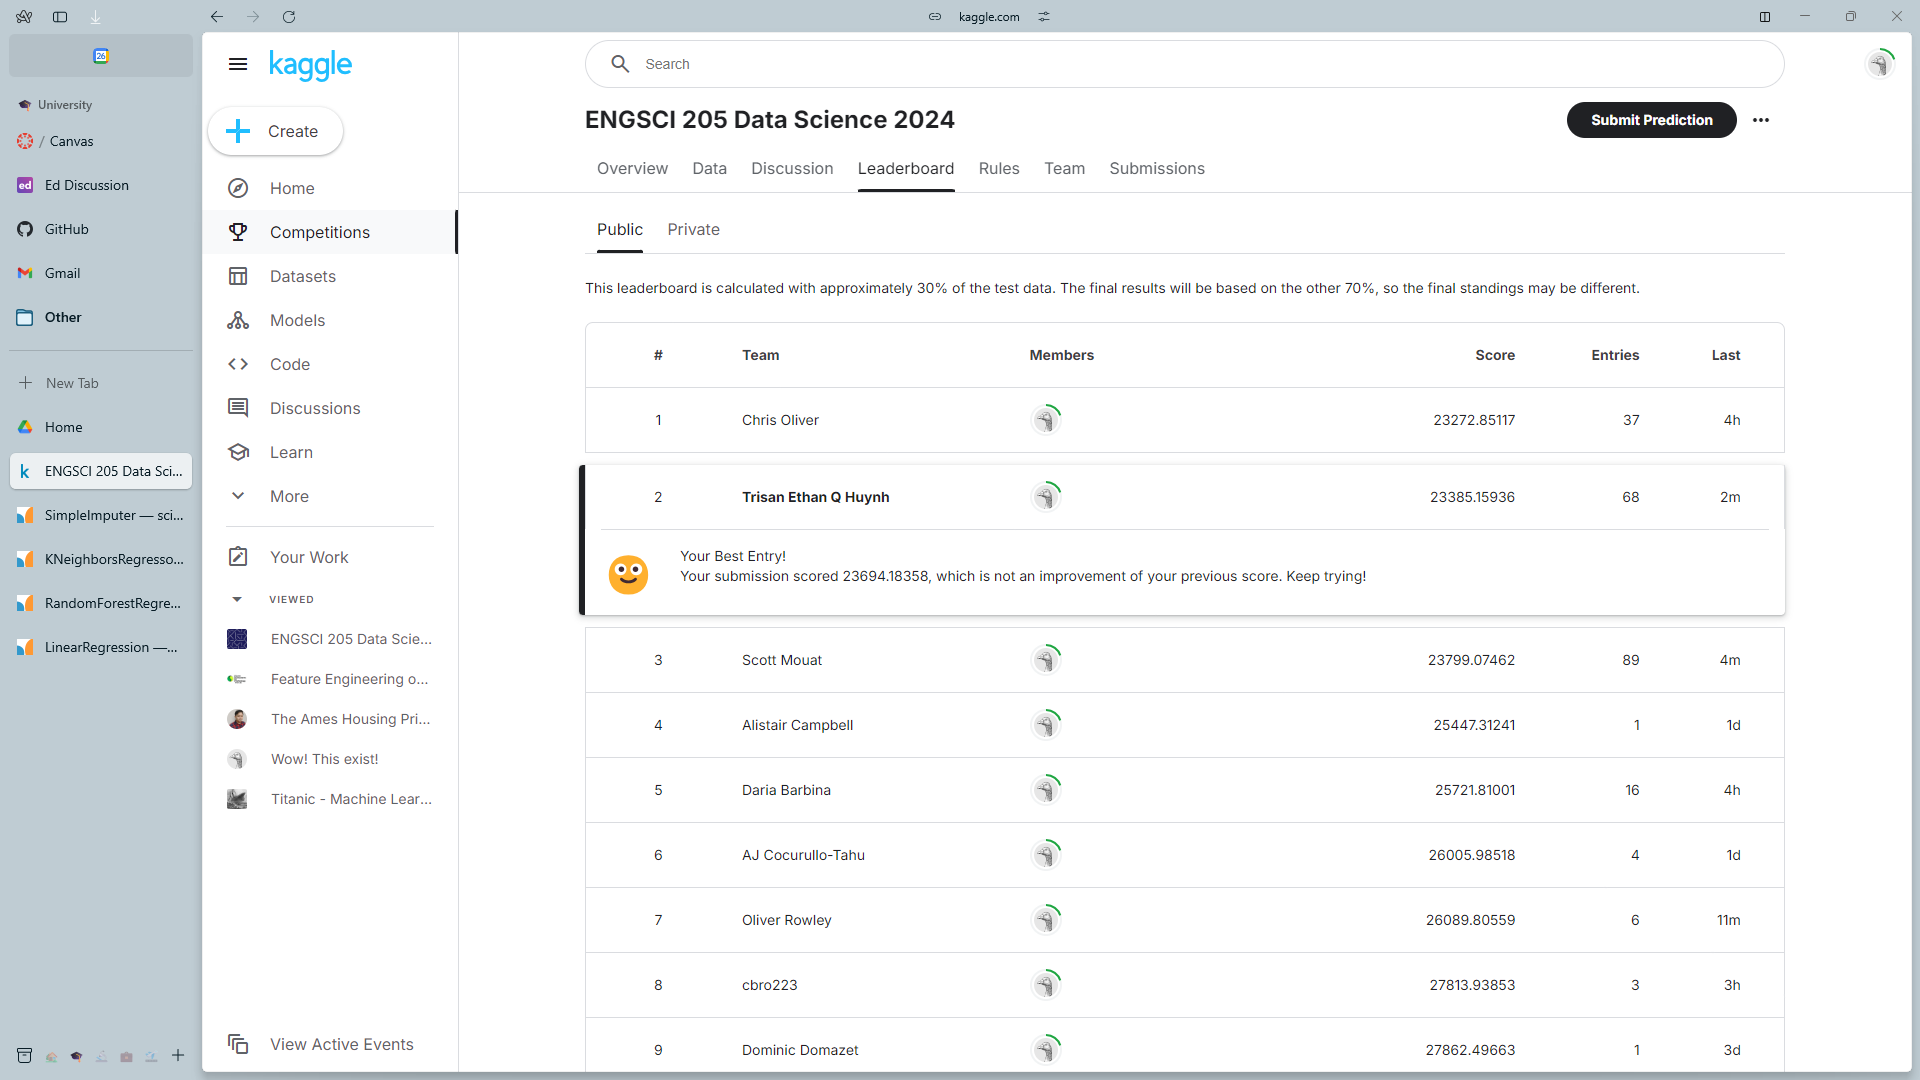

In [19]:
from IPython.display import Image
Image(filename='data\\kaggle.png')

### Use the best model w/ tuned static hyperparameters (faster to run, not part of assignment)

In [44]:
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import cross_val_predict
from sklearn.model_selection import GridSearchCV

rmse = lambda t, p: np.sqrt(mean_squared_error(t, p))

X_train_processed = process_X_data(X_train)
X_test_processed = process_X_data(X_test, True)

GBR = GradientBoostingRegressor(n_estimators=400, max_depth=2)
GBR.fit(X_train_processed, y_train)
print(rmse(y_train, cross_val_predict(GBR, X_train_processed, y_train)))
y_pred = pd.Series(GBR.predict(X_test_processed), name="SalePrice", index=X_test.index)
y_pred.to_csv("test_prediction.csv", header=True)

25270.204478838266
